<a href="https://colab.research.google.com/github/juli-ter/COINS/blob/main/IKS_LMM_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear mixed-effects analysis of Integration Kernel Steepness (IKS)

This notebook is adapted to the uploaded `iks_long.csv`.

The primary model is:

\[
IKS ∼ volatility × noise + (1 ¦ subject)
\]

Here:

- `iks` is the dependent variable;
- `volatility` has two levels: stable and volatile;
- `noise` has three levels: low, medium, and high;
- `(1 | subject)` accounts for repeated observations from the same participant;
- each participant contributes repeated session × condition estimates;
- only rows marked `valid_for_model == TRUE` are included.

IKS is already a derived regression-kernel measure, so it is analysed on its original scale and is **not log-transformed**.


In [ ]:
# Install required packages if necessary.
required_packages <- c(
  "readr",
  "dplyr",
  "tidyr",
  "ggplot2",
  "lme4",
  "lmerTest",
  "emmeans",
  "sjPlot",
  "performance",
  "see"
)

missing_packages <- required_packages[
  !required_packages %in% rownames(installed.packages())
]

if (length(missing_packages) > 0) {
  install.packages(
    missing_packages,
    repos = "https://cloud.r-project.org"
  )
}


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘numDeriv’, ‘estimability’, ‘mvtnorm’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’, ‘correlation’, ‘effectsize’, ‘modelbased’, ‘patchwork’




In [ ]:
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(emmeans)
library(sjPlot)
library(performance)
library(see)

# Larger plots inside Jupyter / Colab.
options(
  repr.plot.width = 11,
  repr.plot.height = 7,
  repr.plot.res = 150
)

theme_set(
  theme_minimal(base_size = 15)
)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'


Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




## 1. Load the IKS data


In [ ]:
candidate_paths <- c(
  "iks_long.csv",
  "/content/iks_long.csv"
)

data_path <- candidate_paths[file.exists(candidate_paths)][1]

if (is.na(data_path)) {
  stop(
    "iks_long.csv was not found. ",
    "Place it in the notebook folder or upload it to /content/."
  )
}

dataset <- read_csv(
  data_path,
  show_col_types = FALSE
)

cat("Loaded:", data_path, "\n")
cat("Rows:", nrow(dataset), "\n")
cat("Participants:", n_distinct(dataset$subject), "\n")

head(dataset)


Loaded: iks_long.csv 
Rows: 528 
Participants: 22 


subject,session,volatility,noise,noise_deg,n_movements,n_valid_movements,beta_t_minus_5,beta_t_minus_4,beta_t_minus_3,beta_t_minus_2,beta_t_minus_1,iks,valid_for_model
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
sub-01,1,stable,low,10,138,137,-0.12616554,0.01827688,-0.01709783,0.21928521,0.29382325,0.07453804,TRUE
sub-01,1,stable,medium,20,101,100,0.08197511,0.22884604,0.15137744,0.31156168,0.08555489,-0.22600679,TRUE
sub-01,1,stable,high,30,98,98,0.08719503,0.03028571,0.21295100,0.17374180,0.44995080,0.27620900,TRUE
sub-01,1,volatile,low,10,154,152,-0.04018933,0.16575631,-0.11900720,0.04174742,0.58794361,0.54619619,TRUE
sub-01,1,volatile,medium,20,85,85,-0.08188048,-0.17123303,0.11806331,0.10935999,0.52960353,0.42024354,TRUE
sub-01,1,volatile,high,30,88,88,0.03156109,-0.02234212,0.20062552,0.31248158,0.36695926,0.05447768,TRUE


In [ ]:
library(dplyr)
library(readr)

iks_data <- read_csv(
  "iks_long.csv",
  show_col_types = FALSE
)

iks_data_no_medium <- iks_data %>%
  filter(noise != "medium")

write_csv(
  iks_data_no_medium,
  "iks_long_no_medium.csv"
)

In [ ]:
cat("Rows:", nrow(iks_data_no_medium), "\n")
cat("Participants:", n_distinct(iks_data_no_medium$subject), "\n")
head(iks_data_no_medium)

Rows: 352 
Participants: 22 


subject,session,volatility,noise,noise_deg,n_movements,n_valid_movements,beta_t_minus_5,beta_t_minus_4,beta_t_minus_3,beta_t_minus_2,beta_t_minus_1,iks,valid_for_model
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
sub-01,1,stable,low,10,138,137,-0.12616554,0.01827688,-0.017097834,0.21928521,0.2938232,0.07453804,TRUE
sub-01,1,stable,high,30,98,98,0.08719503,0.03028571,0.212951002,0.17374180,0.4499508,0.27620900,TRUE
sub-01,1,volatile,low,10,154,152,-0.04018933,0.16575631,-0.119007196,0.04174742,0.5879436,0.54619619,TRUE
sub-01,1,volatile,high,30,88,88,0.03156109,-0.02234212,0.200625524,0.31248158,0.3669593,0.05447768,TRUE
sub-01,2,stable,low,10,127,125,-0.11340576,-0.03705743,0.008727672,0.12044524,0.4307105,0.31026522,TRUE
sub-01,2,stable,high,30,91,91,-0.05384005,0.30377247,-0.003293727,0.13343043,0.3968941,0.26346364,TRUE


In [ ]:
dataset <- iks_data_no_medium

In [ ]:
required_columns <- c(
  "subject",
  "session",
  "volatility",
  "noise",
  "noise_deg",
  "n_movements",
  "n_valid_movements",
  "beta_t_minus_5",
  "beta_t_minus_4",
  "beta_t_minus_3",
  "beta_t_minus_2",
  "beta_t_minus_1",
  "iks",
  "valid_for_model"
)

missing_columns <- setdiff(
  required_columns,
  colnames(dataset)
)

if (length(missing_columns) > 0) {
  stop(
    "Missing required columns: ",
    paste(missing_columns, collapse = ", ")
  )
}

colnames(dataset)


[1] "subject"           "session"           "volatility"       
 [4] "noise"             "noise_deg"         "n_movements"      
 [7] "n_valid_movements" "beta_t_minus_5"    "beta_t_minus_4"   
[10] "beta_t_minus_3"    "beta_t_minus_2"    "beta_t_minus_1"   
[13] "iks"               "valid_for_model"

## 2. Prepare the data

The primary model includes only rows marked `valid_for_model`.

The file contains the five regression-kernel weights as well as the scalar IKS value:

\[
IKS = beta_{t-1} - beta_{t-2}.
\]


In [ ]:
dataset <- dataset %>%
  mutate(
    subject = factor(subject),

    session = factor(session),

    volatility = factor(
      tolower(trimws(as.character(volatility))),
      levels = c("stable", "volatile")
    ),

    noise = factor(
      tolower(trimws(as.character(noise))),
      levels = c("low", "high")
    ),

    valid_for_model = (
      tolower(as.character(valid_for_model))
      %in% c("true", "1", "yes")
    ),

    iks = as.numeric(iks),
    n_movements = as.numeric(n_movements),
    n_valid_movements = as.numeric(n_valid_movements),

    beta_t_minus_5 = as.numeric(beta_t_minus_5),
    beta_t_minus_4 = as.numeric(beta_t_minus_4),
    beta_t_minus_3 = as.numeric(beta_t_minus_3),
    beta_t_minus_2 = as.numeric(beta_t_minus_2),
    beta_t_minus_1 = as.numeric(beta_t_minus_1)
  )

dataset[sapply(dataset, is.infinite)] <- NA

cat("Missing values by column:\n")
print(colSums(is.na(dataset)))

cat("\nRows by condition and validity:\n")
print(
  dataset %>%
    count(
      volatility,
      noise,
      valid_for_model
    )
)


Missing values by column:
          subject           session        volatility             noise 
                0                 0                 0                 0 
        noise_deg       n_movements n_valid_movements    beta_t_minus_5 
                0                 0                 0                 0 
   beta_t_minus_4    beta_t_minus_3    beta_t_minus_2    beta_t_minus_1 
                0                 0                 0                 0 
              iks   valid_for_model 
                0                 0 

Rows by condition and validity:
# A tibble: 4 × 4
  volatility noise valid_for_model     n
  <fct>      <fct> <lgl>           <int>
1 stable     low   TRUE               88
2 stable     high  TRUE               88
3 volatile   low   TRUE               88
4 volatile   high  TRUE               88


In [ ]:
iks_data <- dataset %>%
  filter(
    valid_for_model,
    !is.na(iks),
    is.finite(iks),
    !is.na(subject),
    !is.na(volatility),
    !is.na(noise)
  )

# Sum coding for factorial Type-III tests.
contrasts(iks_data$volatility) <- contr.sum(2)
contrasts(iks_data$noise) <- contr.sum(2)

cat("Rows used in the IKS model:", nrow(iks_data), "\n")
cat("Participants used:", n_distinct(iks_data$subject), "\n")

iks_data %>%
  group_by(
    volatility,
    noise
  ) %>%
  summarise(
    n = n(),
    mean_iks = mean(iks),
    median_iks = median(iks),
    sd_iks = sd(iks),
    mean_valid_movements = mean(n_valid_movements),
    .groups = "drop"
  )


Rows used in the IKS model: 352 
Participants used: 22 


volatility,noise,n,mean_iks,median_iks,sd_iks,mean_valid_movements
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
stable,low,88,0.2803541,0.3045513,0.3207419,76.37500
stable,high,88,0.2900732,0.2729169,0.3197573,52.73864
volatile,low,88,0.4891141,0.4861837,0.3140200,95.86364
volatile,high,88,0.2669523,0.2580096,0.2542289,52.75000


## 3. Descriptive plots


In [ ]:
output_dir <- "iks_lmm_outputs"

dir.create(
  output_dir,
  showWarnings = FALSE,
  recursive = TRUE
)


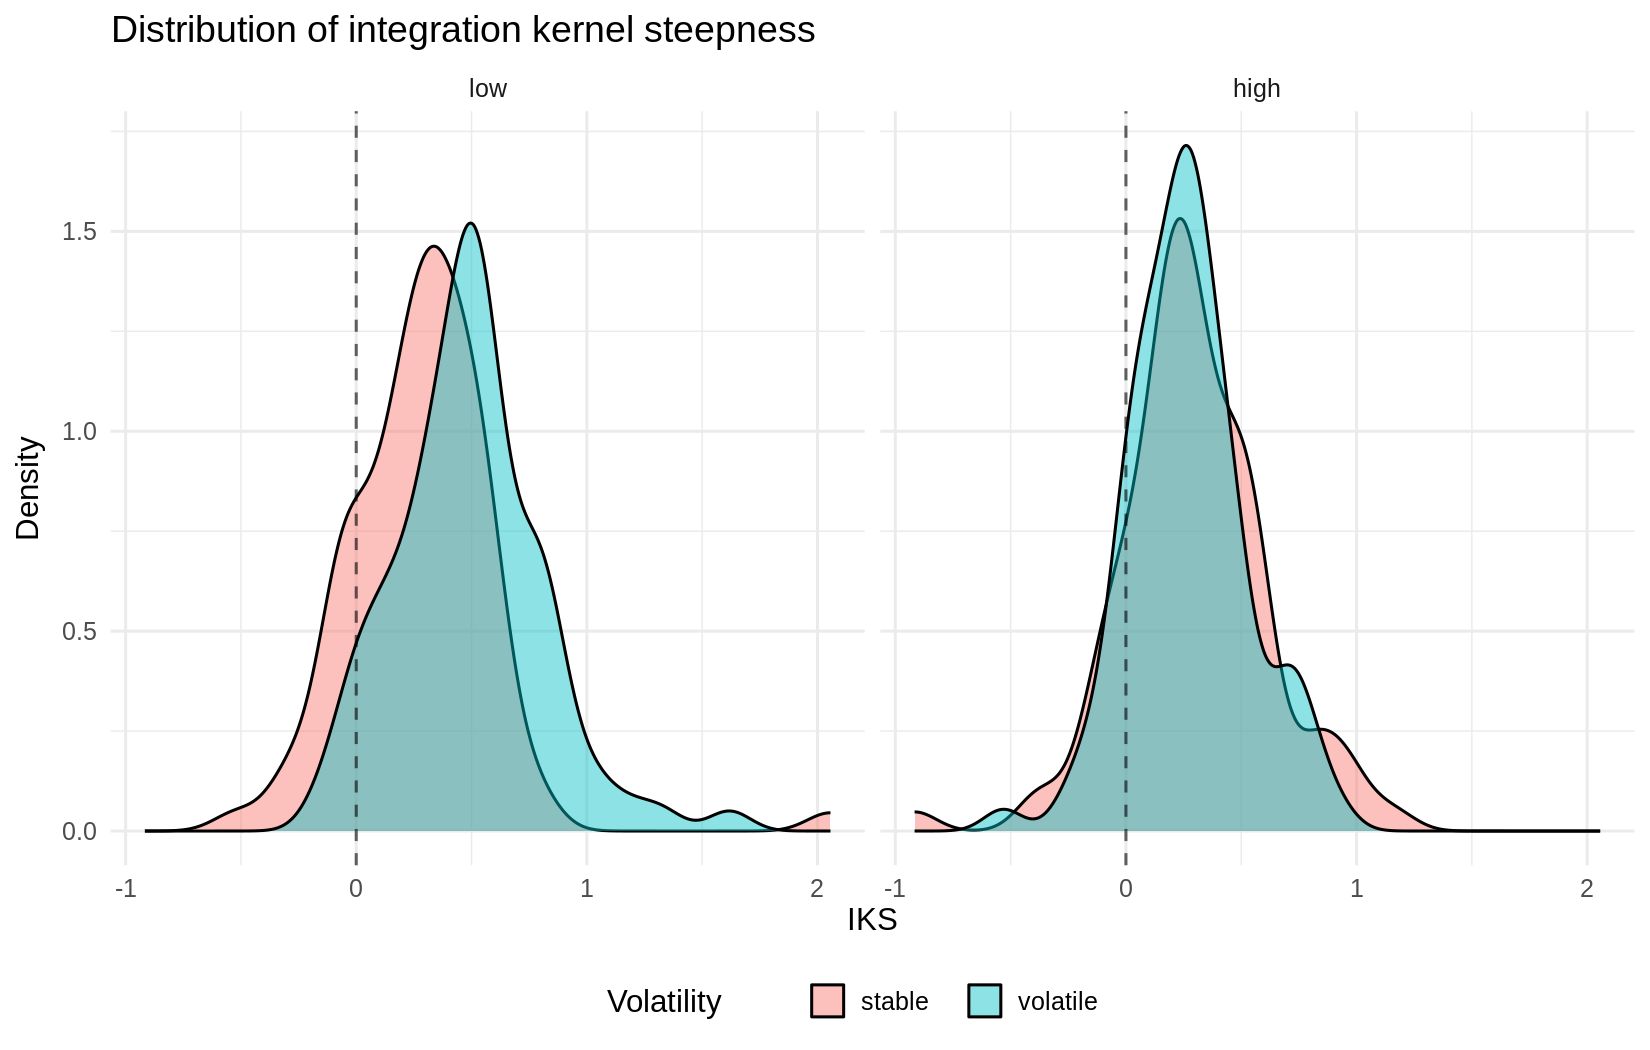

In [ ]:
# Distribution of IKS values.
p_density <- ggplot(
  iks_data,
  aes(
    x = iks,
    fill = volatility
  )
) +
  geom_density(
    alpha = 0.45
  ) +
  facet_wrap(
    ~ noise,
    nrow = 1
  ) +
  geom_vline(
    xintercept = 0,
    linetype = "dashed",
    alpha = 0.6
  ) +
  labs(
    title = "Distribution of integration kernel steepness",
    x = "IKS",
    y = "Density",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_density

ggsave(
  file.path(
    output_dir,
    "iks_density.png"
  ),
  p_density,
  width = 12,
  height = 5,
  dpi = 300
)


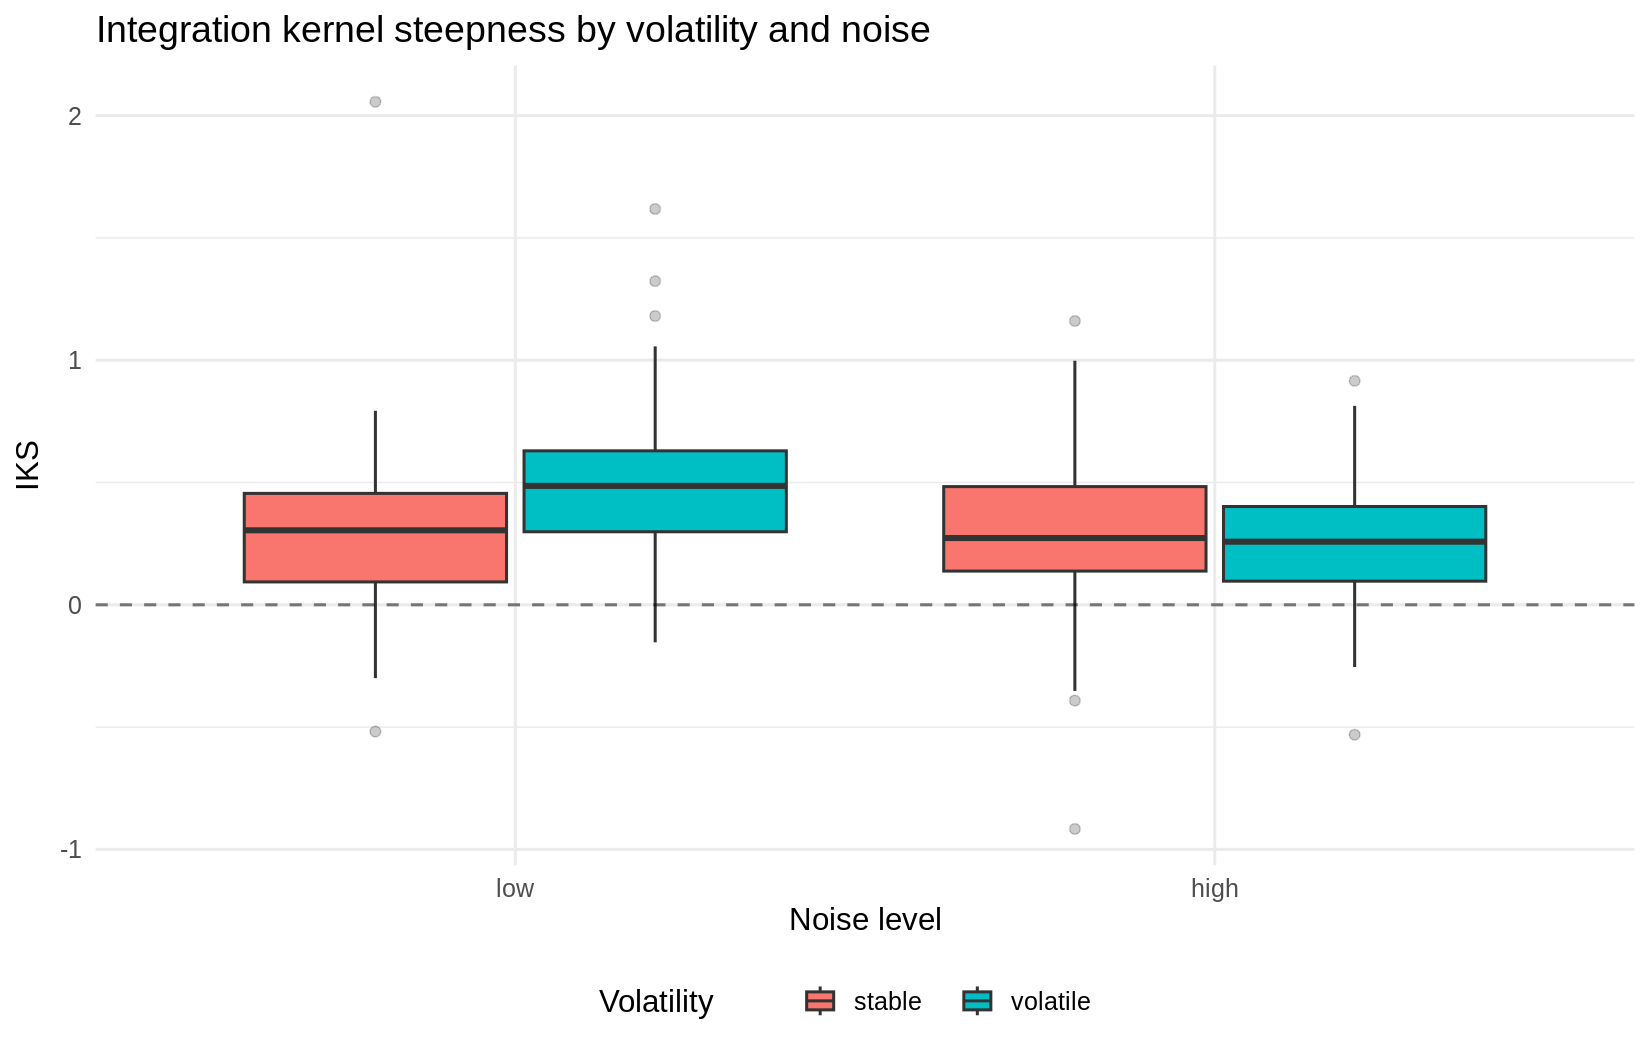

In [ ]:
# Raw IKS by condition.
p_box <- ggplot(
  iks_data,
  aes(
    x = noise,
    y = iks,
    fill = volatility
  )
) +
  geom_boxplot(
    position = position_dodge(width = 0.8),
    outlier.alpha = 0.25
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    alpha = 0.5
  ) +
  labs(
    title = "Integration kernel steepness by volatility and noise",
    x = "Noise level",
    y = "IKS",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_box

ggsave(
  file.path(
    output_dir,
    "iks_boxplot.png"
  ),
  p_box,
  width = 9,
  height = 6,
  dpi = 300
)


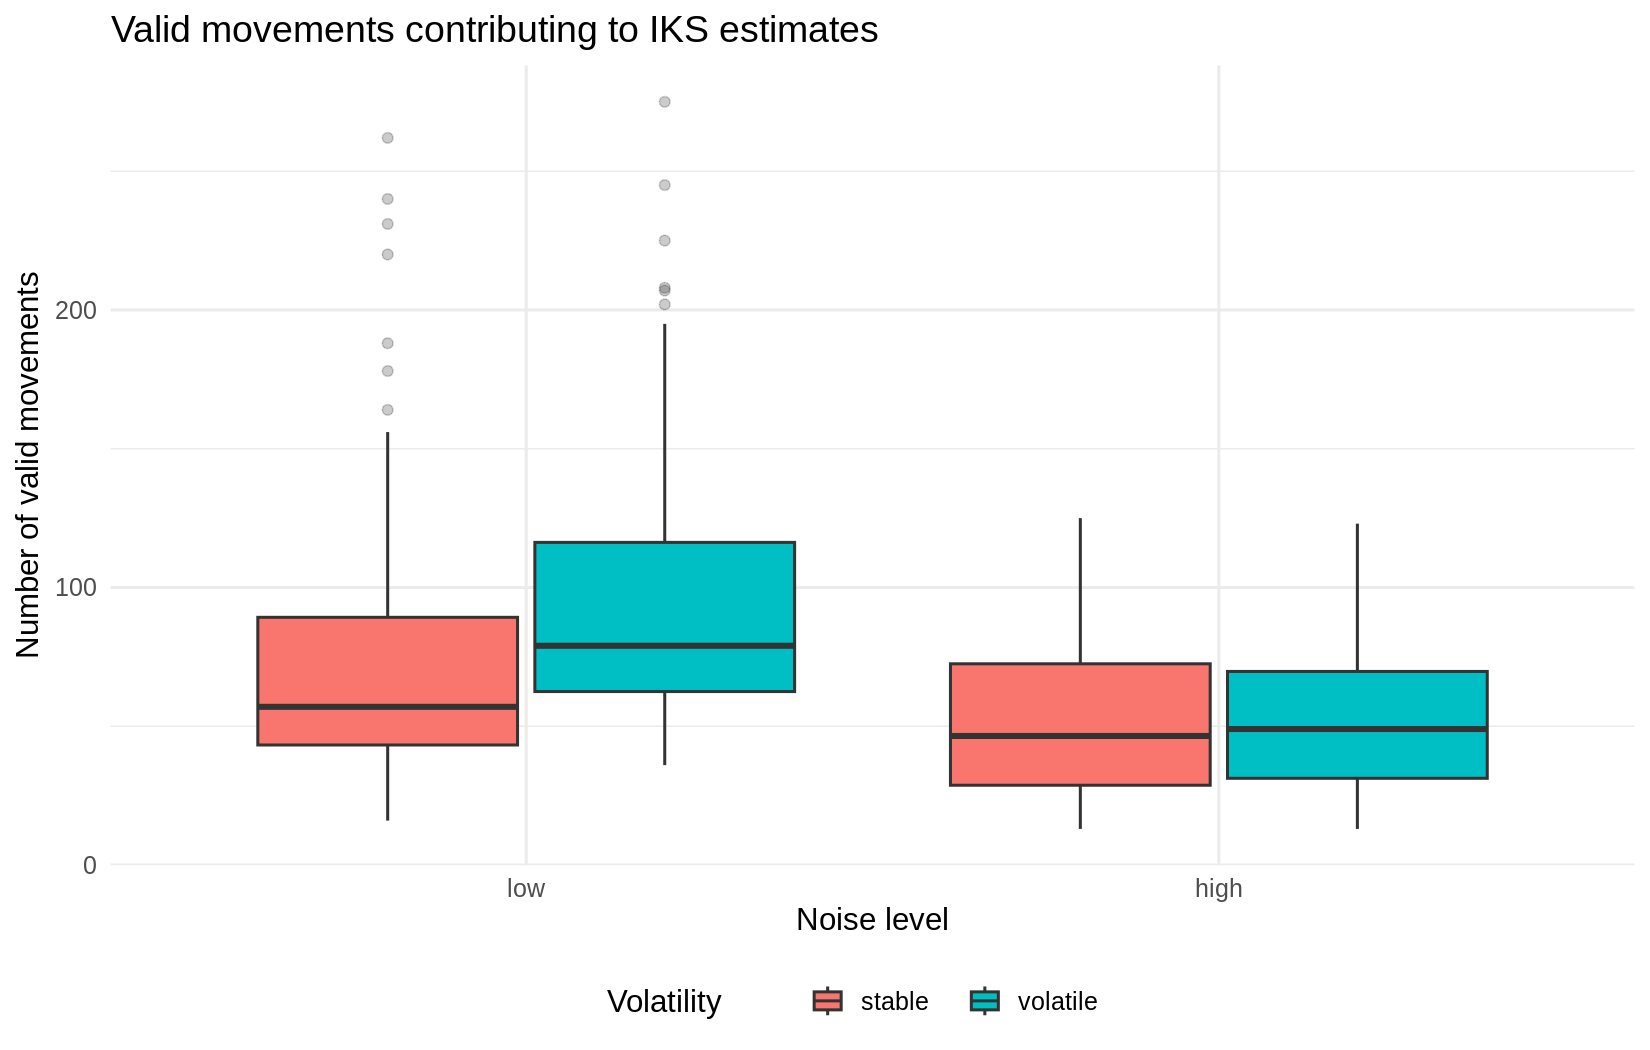

In [ ]:
# Number of valid movements contributing to each kernel estimate.
p_movements <- ggplot(
  iks_data,
  aes(
    x = noise,
    y = n_valid_movements,
    fill = volatility
  )
) +
  geom_boxplot(
    position = position_dodge(width = 0.8),
    outlier.alpha = 0.25
  ) +
  labs(
    title = "Valid movements contributing to IKS estimates",
    x = "Noise level",
    y = "Number of valid movements",
    fill = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_movements

ggsave(
  file.path(
    output_dir,
    "iks_valid_movements.png"
  ),
  p_movements,
  width = 9,
  height = 6,
  dpi = 300
)


## 4. Full integration kernels

Because `iks_long.csv` also contains the five regression weights, we can plot the complete integration kernels rather than only the scalar IKS value.

This plot is useful for interpreting *why* IKS differs between conditions.


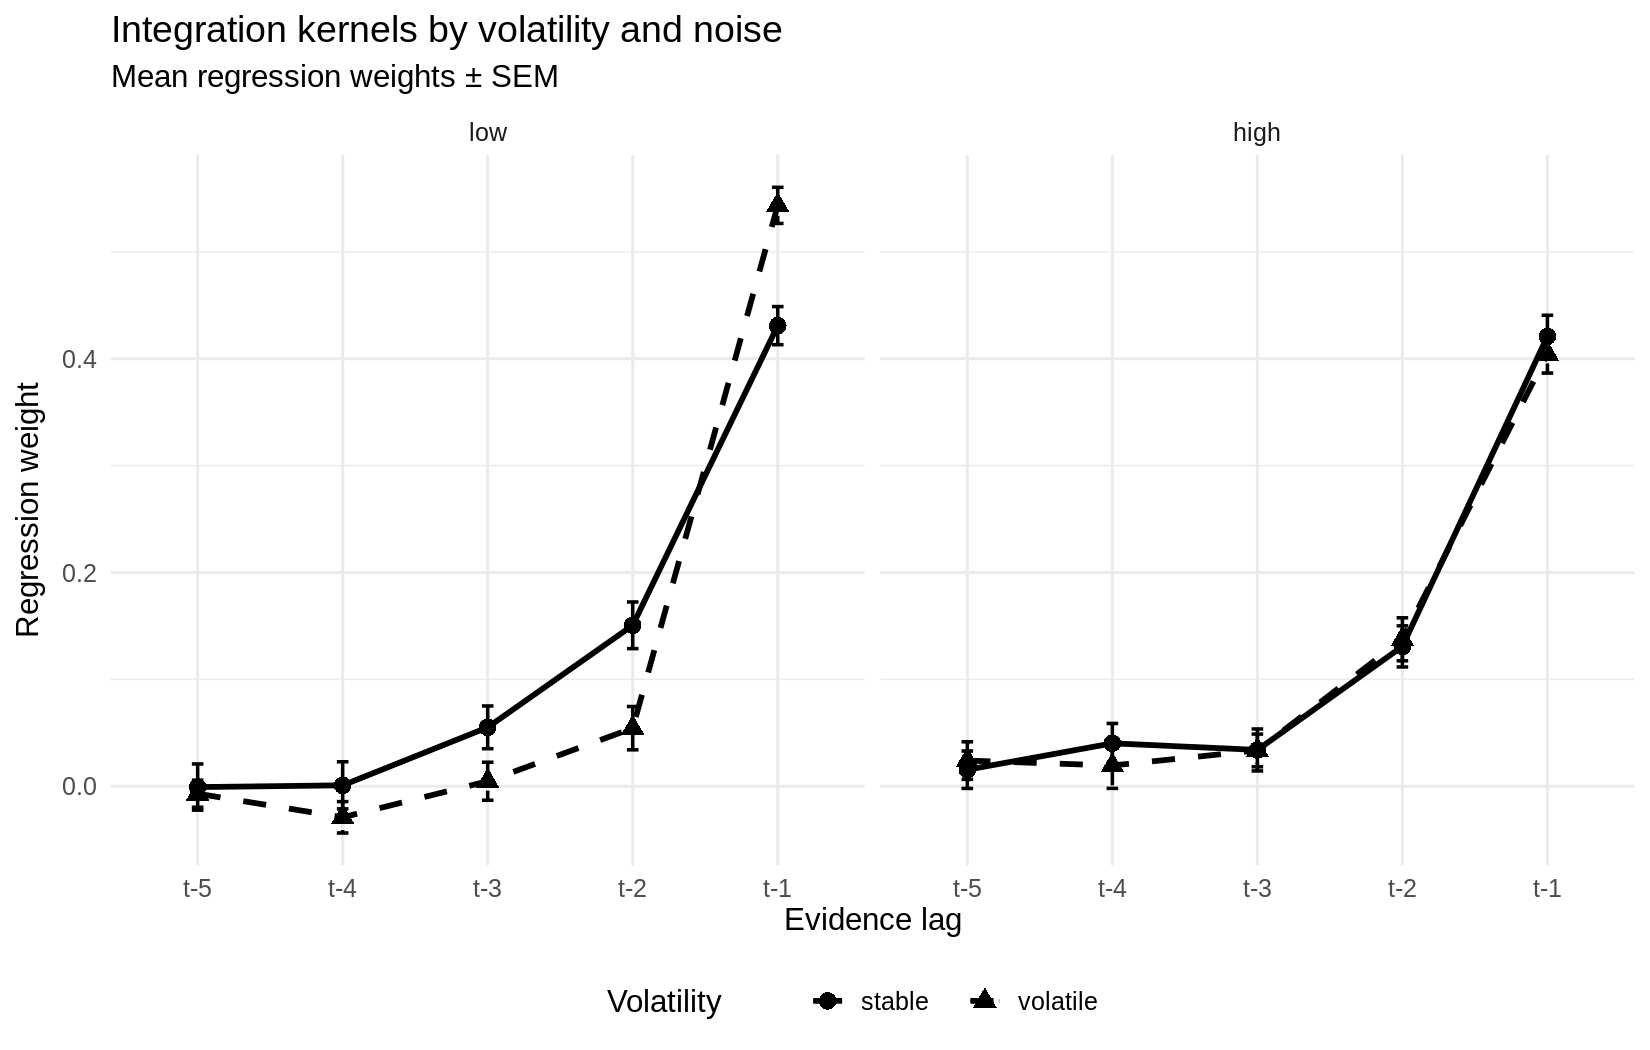

In [ ]:
kernel_long <- iks_data %>%
  select(
    subject,
    session,
    volatility,
    noise,
    beta_t_minus_5,
    beta_t_minus_4,
    beta_t_minus_3,
    beta_t_minus_2,
    beta_t_minus_1
  ) %>%
  pivot_longer(
    cols = starts_with("beta_t_minus_"),
    names_to = "lag",
    values_to = "weight"
  ) %>%
  mutate(
    lag = factor(
      lag,
      levels = c(
        "beta_t_minus_5",
        "beta_t_minus_4",
        "beta_t_minus_3",
        "beta_t_minus_2",
        "beta_t_minus_1"
      ),
      labels = c(
        "t-5",
        "t-4",
        "t-3",
        "t-2",
        "t-1"
      )
    )
  )

kernel_summary <- kernel_long %>%
  group_by(
    volatility,
    noise,
    lag
  ) %>%
  summarise(
    mean_weight = mean(
      weight,
      na.rm = TRUE
    ),
    se_weight = sd(
      weight,
      na.rm = TRUE
    ) / sqrt(
      sum(!is.na(weight))
    ),
    .groups = "drop"
  )

p_kernel <- ggplot(
  kernel_summary,
  aes(
    x = lag,
    y = mean_weight,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.3
  ) +
  geom_point(
    size = 3.5
  ) +
  geom_errorbar(
    aes(
      ymin = mean_weight - se_weight,
      ymax = mean_weight + se_weight
    ),
    width = 0.08,
    linewidth = 0.8
  ) +
  facet_wrap(
    ~ noise,
    nrow = 1
  ) +
  scale_linetype_manual(
    values = c(
      stable = "solid",
      volatile = "dashed"
    )
  ) +
  labs(
    title = "Integration kernels by volatility and noise",
    subtitle = "Mean regression weights ± SEM",
    x = "Evidence lag",
    y = "Regression weight",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_kernel

ggsave(
  file.path(
    output_dir,
    "integration_kernels.png"
  ),
  p_kernel,
  width = 14,
  height = 6,
  dpi = 300
)

ggsave(
  file.path(
    output_dir,
    "integration_kernels.pdf"
  ),
  p_kernel,
  width = 14,
  height = 6
)


## 5. Individual participant trajectories


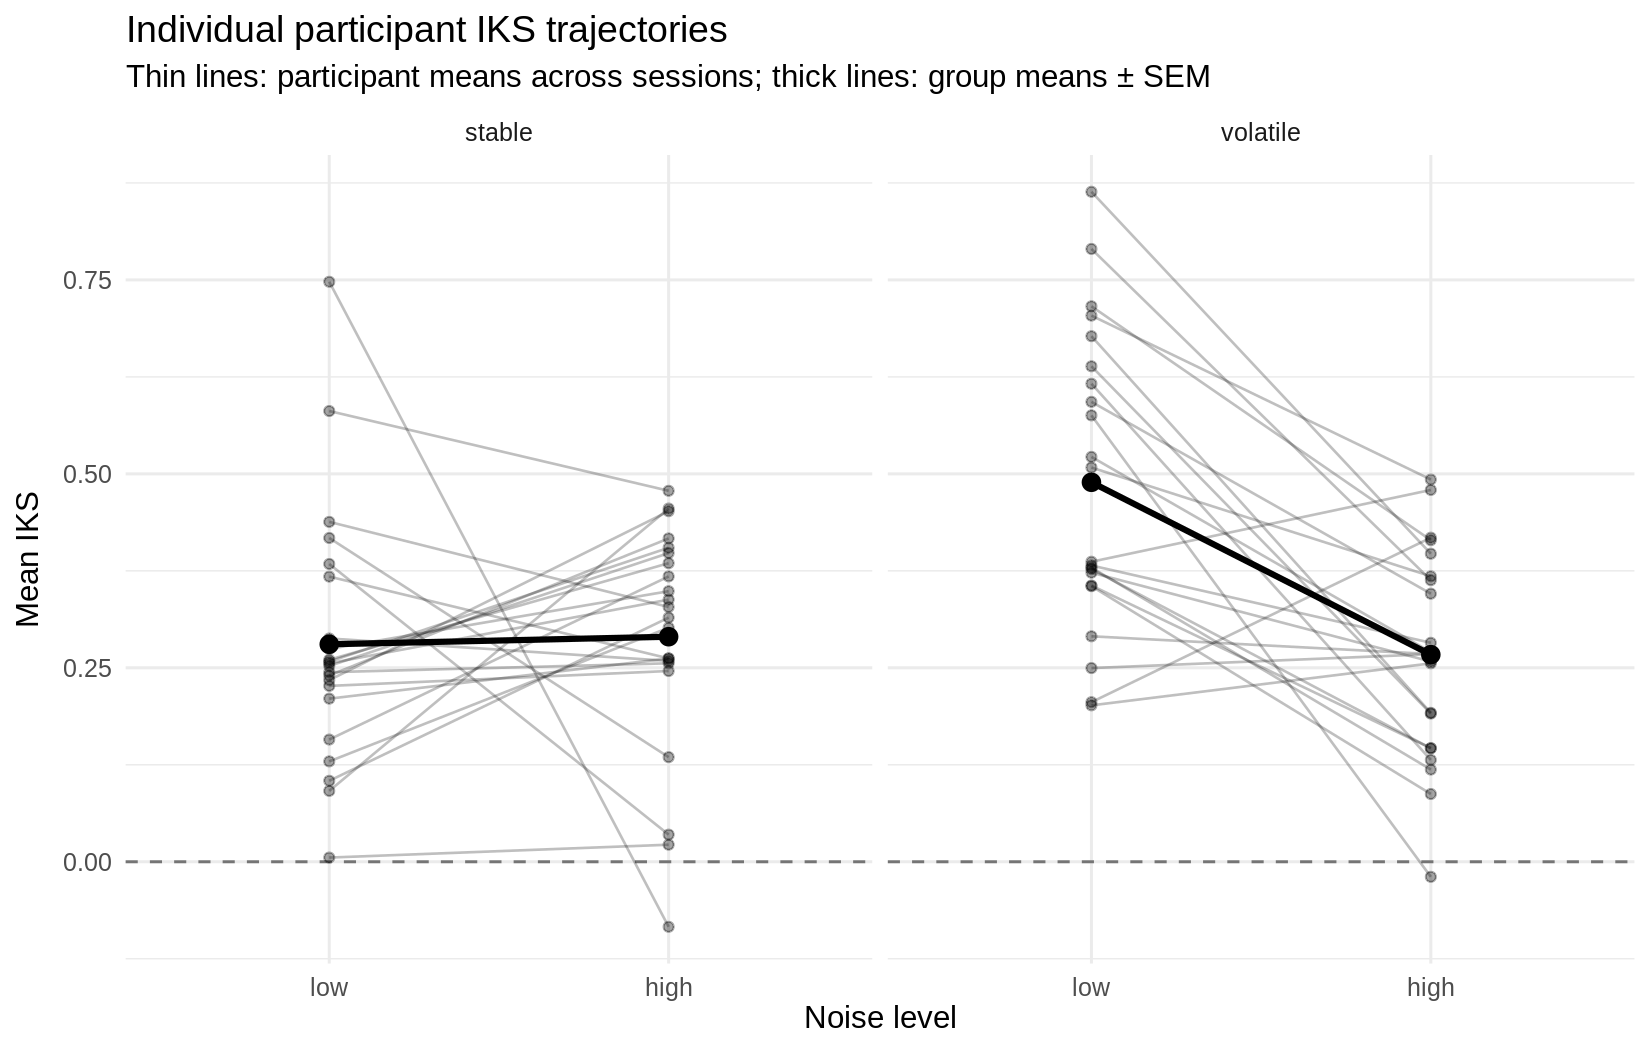

In [ ]:
# Participant means averaged across sessions.
participant_means <- iks_data %>%
  group_by(
    subject,
    volatility,
    noise
  ) %>%
  summarise(
    mean_iks = mean(
      iks,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

group_means <- participant_means %>%
  group_by(
    volatility,
    noise
  ) %>%
  summarise(
    mean_iks = mean(
      mean_iks,
      na.rm = TRUE
    ),
    se_iks = sd(
      mean_iks,
      na.rm = TRUE
    ) / sqrt(
      sum(!is.na(mean_iks))
    ),
    .groups = "drop"
  )

p_individual <- ggplot() +

  geom_line(
    data = participant_means,
    aes(
      x = noise,
      y = mean_iks,
      group = subject
    ),
    alpha = 0.25,
    linewidth = 0.6
  ) +

  geom_point(
    data = participant_means,
    aes(
      x = noise,
      y = mean_iks,
      group = subject
    ),
    alpha = 0.35,
    size = 1.8
  ) +

  geom_line(
    data = group_means,
    aes(
      x = noise,
      y = mean_iks,
      group = 1
    ),
    linewidth = 1.4
  ) +

  geom_point(
    data = group_means,
    aes(
      x = noise,
      y = mean_iks
    ),
    size = 3.5
  ) +

  geom_errorbar(
    data = group_means,
    aes(
      x = noise,
      ymin = mean_iks - se_iks,
      ymax = mean_iks + se_iks
    ),
    width = 0.08,
    linewidth = 0.8
  ) +

  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    alpha = 0.5
  ) +

  facet_wrap(
    ~ volatility
  ) +

  labs(
    title = "Individual participant IKS trajectories",
    subtitle = "Thin lines: participant means across sessions; thick lines: group means ± SEM",
    x = "Noise level",
    y = "Mean IKS"
  )

p_individual

ggsave(
  file.path(
    output_dir,
    "iks_individual_trajectories.png"
  ),
  p_individual,
  width = 12,
  height = 7,
  dpi = 300
)


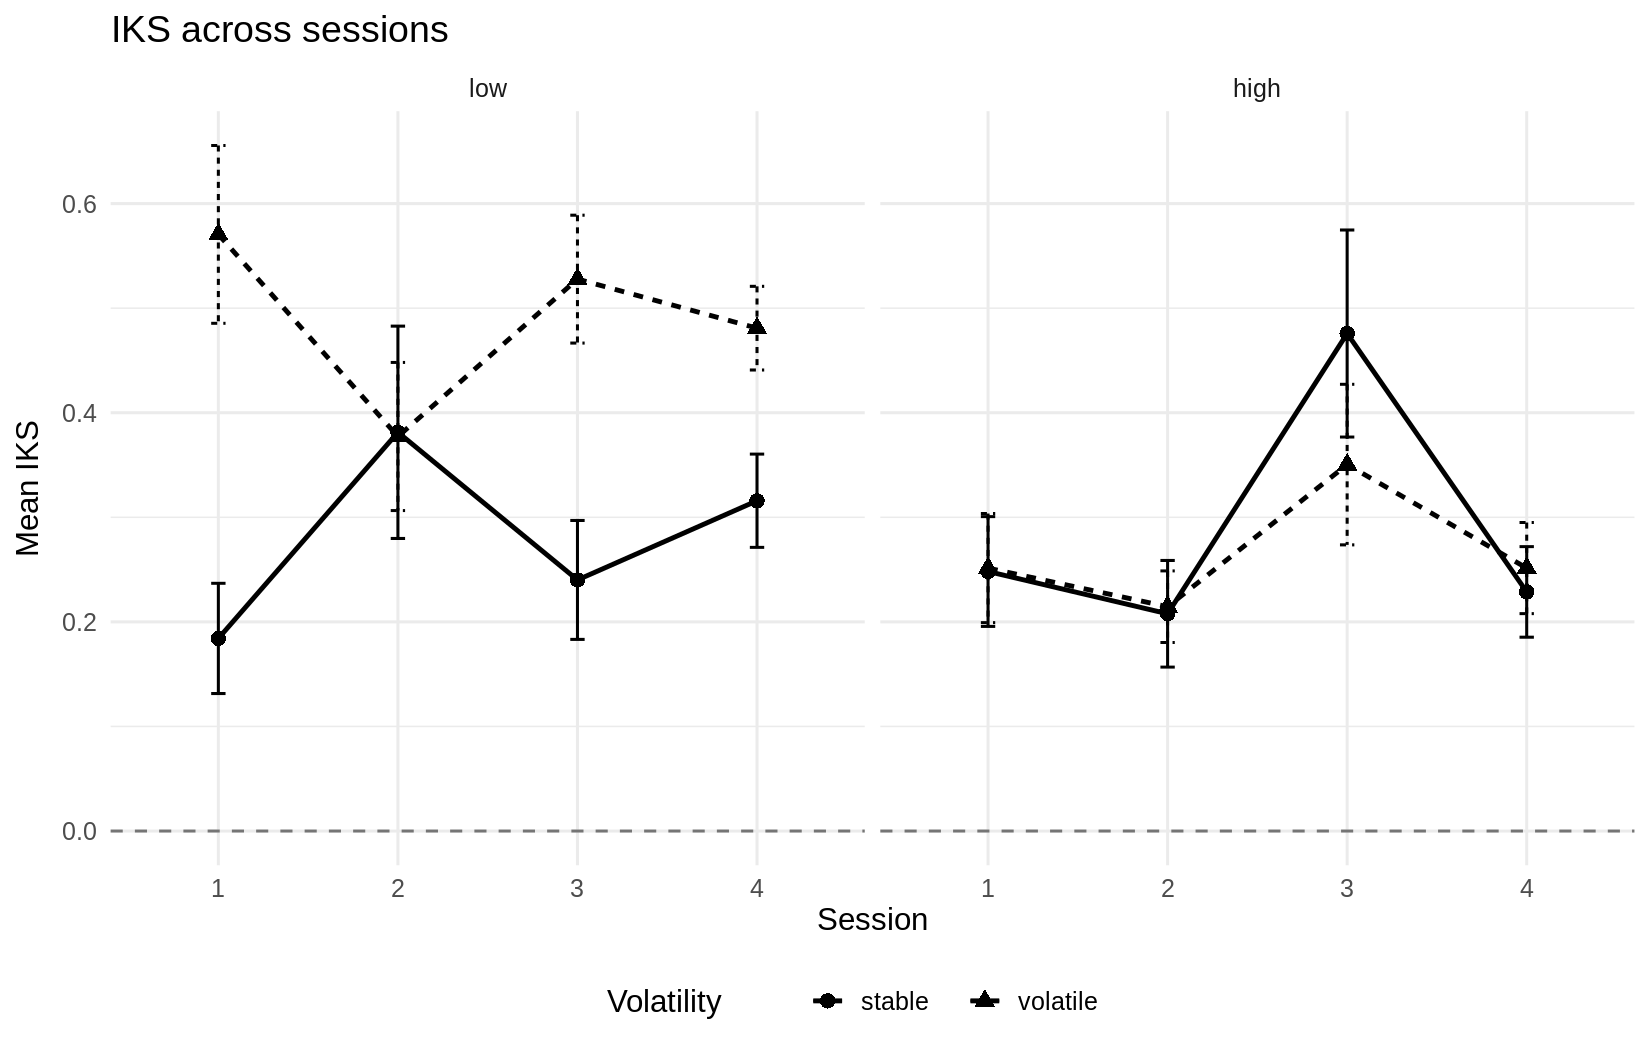

In [ ]:
# Descriptive session plot.
session_means <- iks_data %>%
  group_by(
    session,
    volatility,
    noise
  ) %>%
  summarise(
    mean_iks = mean(iks),
    se_iks = sd(iks) / sqrt(n()),
    .groups = "drop"
  )

p_session <- ggplot(
  session_means,
  aes(
    x = session,
    y = mean_iks,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.1
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = mean_iks - se_iks,
      ymax = mean_iks + se_iks
    ),
    width = 0.08
  ) +
  facet_wrap(
    ~ noise,
    nrow = 1
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    alpha = 0.5
  ) +
  labs(
    title = "IKS across sessions",
    x = "Session",
    y = "Mean IKS",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_session

ggsave(
  file.path(
    output_dir,
    "iks_across_sessions.png"
  ),
  p_session,
  width = 12,
  height = 5,
  dpi = 300
)


## 6. Fit the linear mixed-effects model

The primary model is:

\[
IKS \sim volatility \times noise + (1 \mid subject)
\]

`volatility * noise` includes:

- the main effect of volatility;
- the main effect of noise;
- the volatility × noise interaction.


In [ ]:
model_iks <- lmer(
  iks ~
    volatility * noise +
    (1 | subject),
  data = iks_data,
  REML = FALSE
)

summary(model_iks)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: iks ~ volatility * noise + (1 | subject)
   Data: iks_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    167.1     190.3     -77.5     155.1       346 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.9710 -0.5581 -0.0360  0.5637  5.9473 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.001019 0.03192 
 Residual             0.090025 0.30004 
Number of obs: 352, groups:  subject, 22

Fixed effects:
                    Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)          0.33162    0.01738  22.00000  19.081 3.55e-15 ***
volatility1         -0.04641    0.01599 330.00000  -2.902 0.003957 ** 
noise1               0.05311    0.01599 330.00000   3.321 0.000997 ***
volatility1:noise1  -0.05797    0.01599 330.00000  -3.625 0.000335 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlat

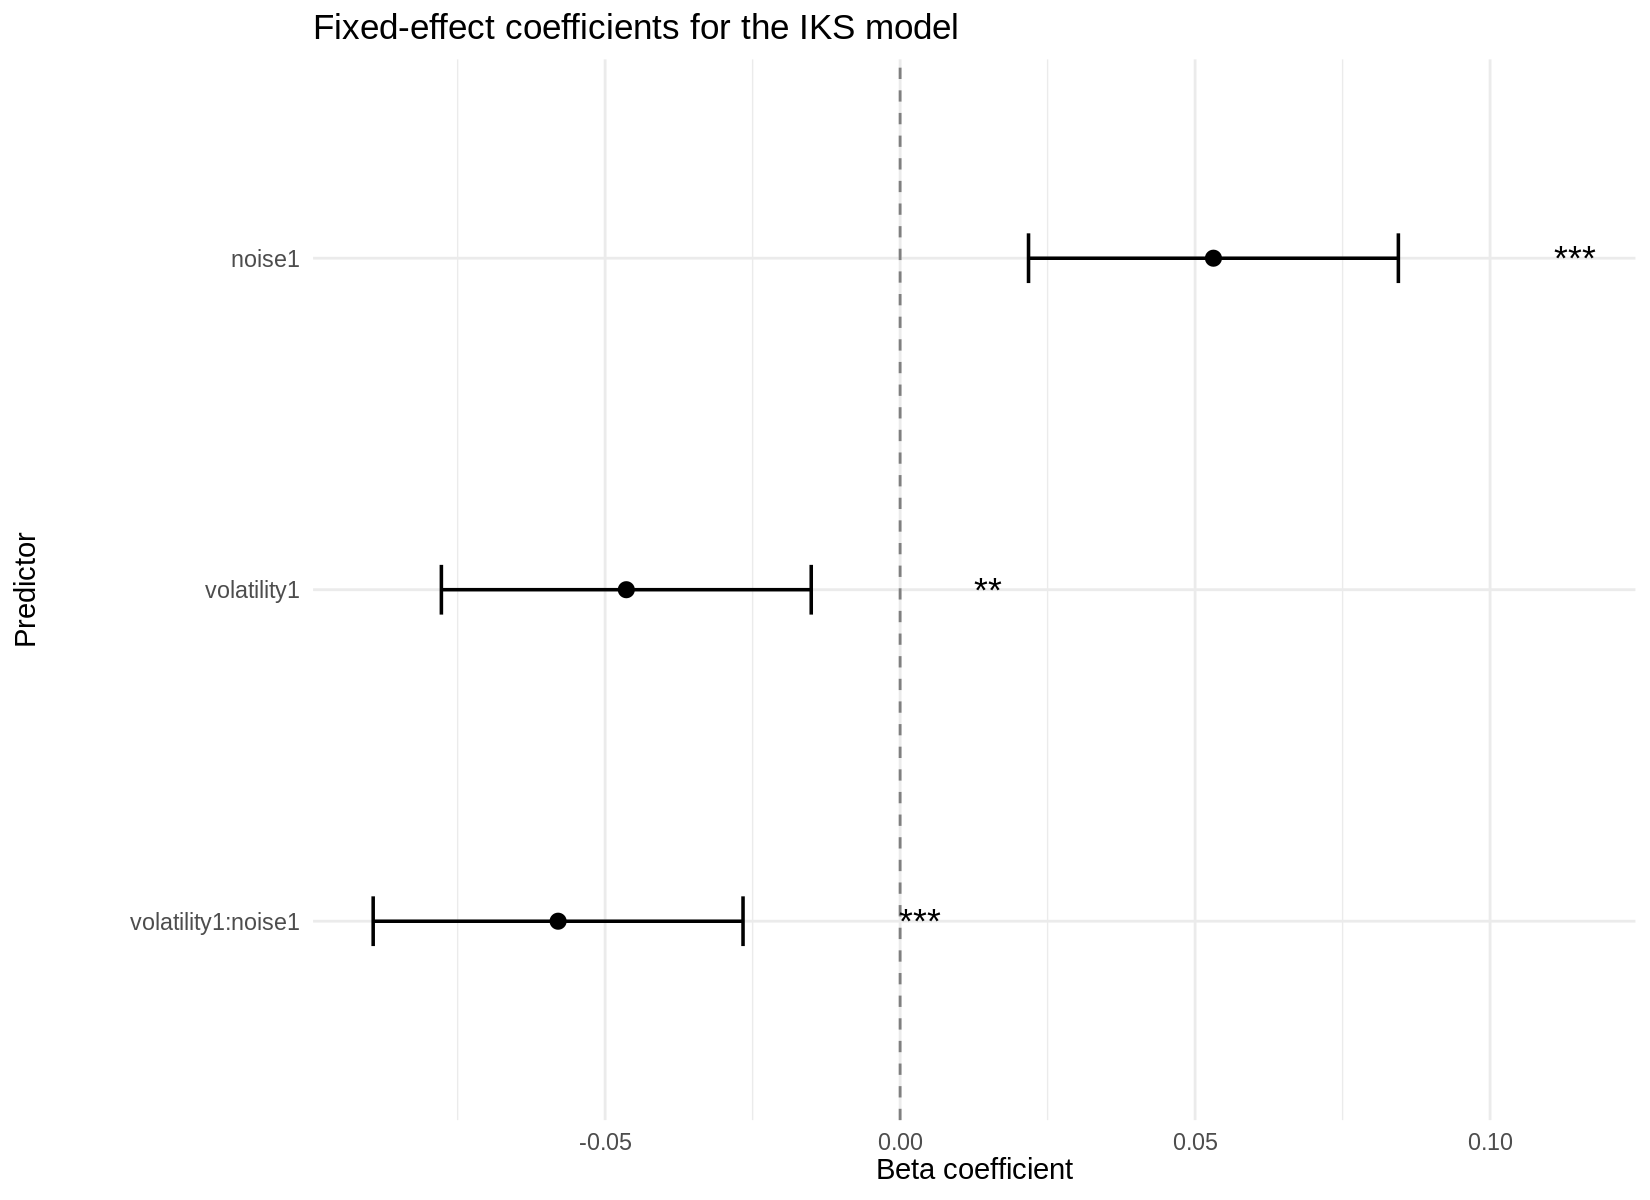

In [ ]:
library(dplyr)
library(ggplot2)

# Extract fixed effects from the model
beta_plot_data <- as.data.frame(
  summary(model_iks)$coefficients
)

beta_plot_data$Effect <- rownames(beta_plot_data)
rownames(beta_plot_data) <- NULL

beta_plot_data <- beta_plot_data %>%
  select(
    Effect,
    Estimate,
    `Std. Error`,
    `Pr(>|t|)`
  ) %>%
  rename(
    Beta = Estimate,
    SE = `Std. Error`,
    p = `Pr(>|t|)`
  ) %>%
  mutate(
    CI_low = Beta - 1.96 * SE,
    CI_high = Beta + 1.96 * SE,
    Significance = case_when(
      p < 0.001 ~ "***",
      p < 0.01  ~ "**",
      p < 0.05  ~ "*",
      TRUE      ~ ""
    )
  )

# Optional: remove intercept if you only want predictors
beta_plot_data_no_intercept <- beta_plot_data %>%
  filter(Effect != "(Intercept)")

# Plot
p_beta <- ggplot(
  beta_plot_data_no_intercept,
  aes(
    x = reorder(Effect, Beta),
    y = Beta
  )
) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed",
    color = "grey50"
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = CI_low,
      ymax = CI_high
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  geom_text(
    aes(
      label = Significance,
      y = CI_high + 0.03
    ),
    size = 6
  ) +
  coord_flip() +
  labs(
    title = "Fixed-effect coefficients for the IKS model",
    x = "Predictor",
    y = "Beta coefficient"
  ) +
  theme_minimal(
    base_size = 14
  )

p_beta

In [ ]:
# Type-III omnibus tests with Satterthwaite degrees of freedom.
anova_iks <- anova(
  model_iks,
  type = 3,
  ddf = "Satterthwaite"
)

anova_iks


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,0.7581606,0.7581606,1,330,8.421689,0.0039569692
noise,0.9929018,0.9929018,1,330,11.029206,0.0009973258
volatility:noise,1.1829130,1.1829130,1,330,13.139861,0.0003346848


In [ ]:
cat(
  "Model converged:",
  is.null(model_iks@optinfo$conv$lme4$messages),
  "\n"
)

cat(
  "Singular fit:",
  isSingular(
    model_iks,
    tol = 1e-4
  ),
  "\n"
)


Model converged: TRUE 
Singular fit: FALSE 


## 7. Estimated marginal means and interaction plot

The estimated marginal means are model-based IKS estimates for the six volatility × noise combinations.

No back-transformation is required because IKS is modelled on its original scale.


In [ ]:
emm_iks <- emmeans(
  model_iks,
  ~ volatility * noise
)

emm_iks_df <- as.data.frame(
  confint(emm_iks)
)

emm_iks_df


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,volatility,noise,emmean,SE,df,lower.CL,upper.CL
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stable,low,0.2803541,0.03270056,192.7792,0.2158573,0.3448509
2,volatile,low,0.4891141,0.03270056,192.7792,0.4246173,0.5536109
3,stable,high,0.2900732,0.03270056,192.7792,0.2255764,0.3545700
4,volatile,high,0.2669523,0.03270056,192.7792,0.2024554,0.3314491


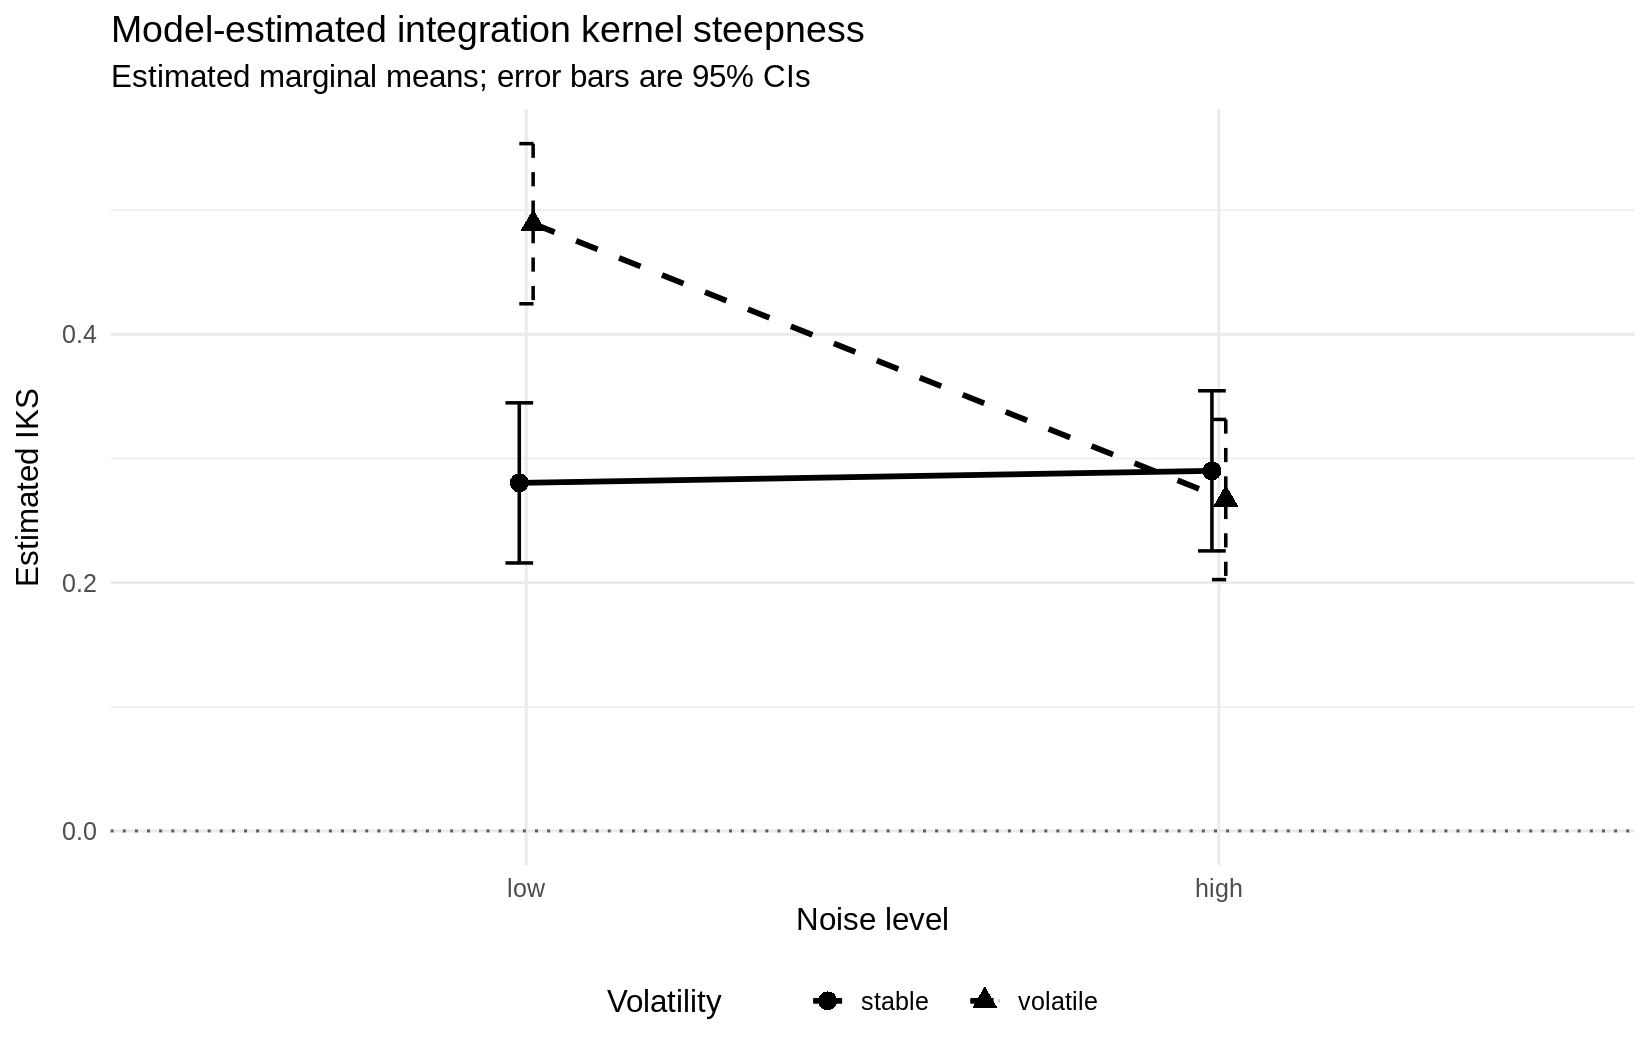

In [ ]:
p_interaction <- ggplot(
  emm_iks_df,
  aes(
    x = noise,
    y = emmean,
    group = volatility,
    linetype = volatility,
    shape = volatility
  )
) +
  geom_line(
    linewidth = 1.3,
    position = position_dodge(width = 0.04)
  ) +
  geom_point(
    size = 3.8,
    position = position_dodge(width = 0.04)
  ) +
  geom_errorbar(
    aes(
      ymin = lower.CL,
      ymax = upper.CL
    ),
    width = 0.08,
    linewidth = 0.8,
    position = position_dodge(width = 0.04)
  ) +
  scale_linetype_manual(
    values = c(
      stable = "solid",
      volatile = "dashed"
    )
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dotted",
    alpha = 0.6
  ) +
  labs(
    title = "Model-estimated integration kernel steepness",
    subtitle = "Estimated marginal means; error bars are 95% CIs",
    x = "Noise level",
    y = "Estimated IKS",
    linetype = "Volatility",
    shape = "Volatility"
  ) +
  theme(
    legend.position = "bottom"
  )

p_interaction

ggsave(
  file.path(
    output_dir,
    "iks_lmm_interaction.png"
  ),
  p_interaction,
  width = 10,
  height = 7,
  dpi = 300
)

ggsave(
  file.path(
    output_dir,
    "iks_lmm_interaction.pdf"
  ),
  p_interaction,
  width = 10,
  height = 7
)


## 8. Holm-corrected post-hoc comparisons


In [ ]:
# Stable vs volatile at each noise level.
emm_volatility_by_noise <- emmeans(
  model_iks,
  ~ volatility | noise
)

posthoc_volatility <- as.data.frame(
  pairs(
    emm_volatility_by_noise,
    adjust = "holm"
  )
)

posthoc_volatility


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,contrast,noise,estimate,SE,df,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stable - volatile,low,-0.20875998,0.04237986,506,-4.9259237,1.139025e-06
2,stable - volatile,medium,-0.10452362,0.04237986,506,-2.4663509,1.398015e-02
3,stable - volatile,high,0.02312096,0.04237986,506,0.5455648,5.856055e-01


In [ ]:
# Pairwise noise comparisons within stable and volatile environments.
emm_noise_by_volatility <- emmeans(
  model_iks,
  ~ noise | volatility
)

posthoc_noise <- as.data.frame(
  pairs(
    emm_noise_by_volatility,
    adjust = "holm"
  )
)

posthoc_noise


Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed



,contrast,volatility,estimate,SE,df,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,low - medium,stable,0.048716926,0.04237986,506,1.1495300,5.056381e-01
2,low - high,stable,-0.009719124,0.04237986,506,-0.2293335,8.187024e-01
3,medium - high,stable,-0.058436050,0.04237986,506,-1.3788635,5.056381e-01
4,low - medium,volatile,0.152953289,0.04237986,506,3.6091028,6.756385e-04
5,low - high,volatile,0.222161819,0.04237986,506,5.2421550,7.005643e-07
6,medium - high,volatile,0.069208530,0.04237986,506,1.6330522,1.030801e-01


## 9. Fixed and random effects


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the sjPlot package.
  Please report the issue at <https://github.com/strengejacke/sjPlot/issues>.”


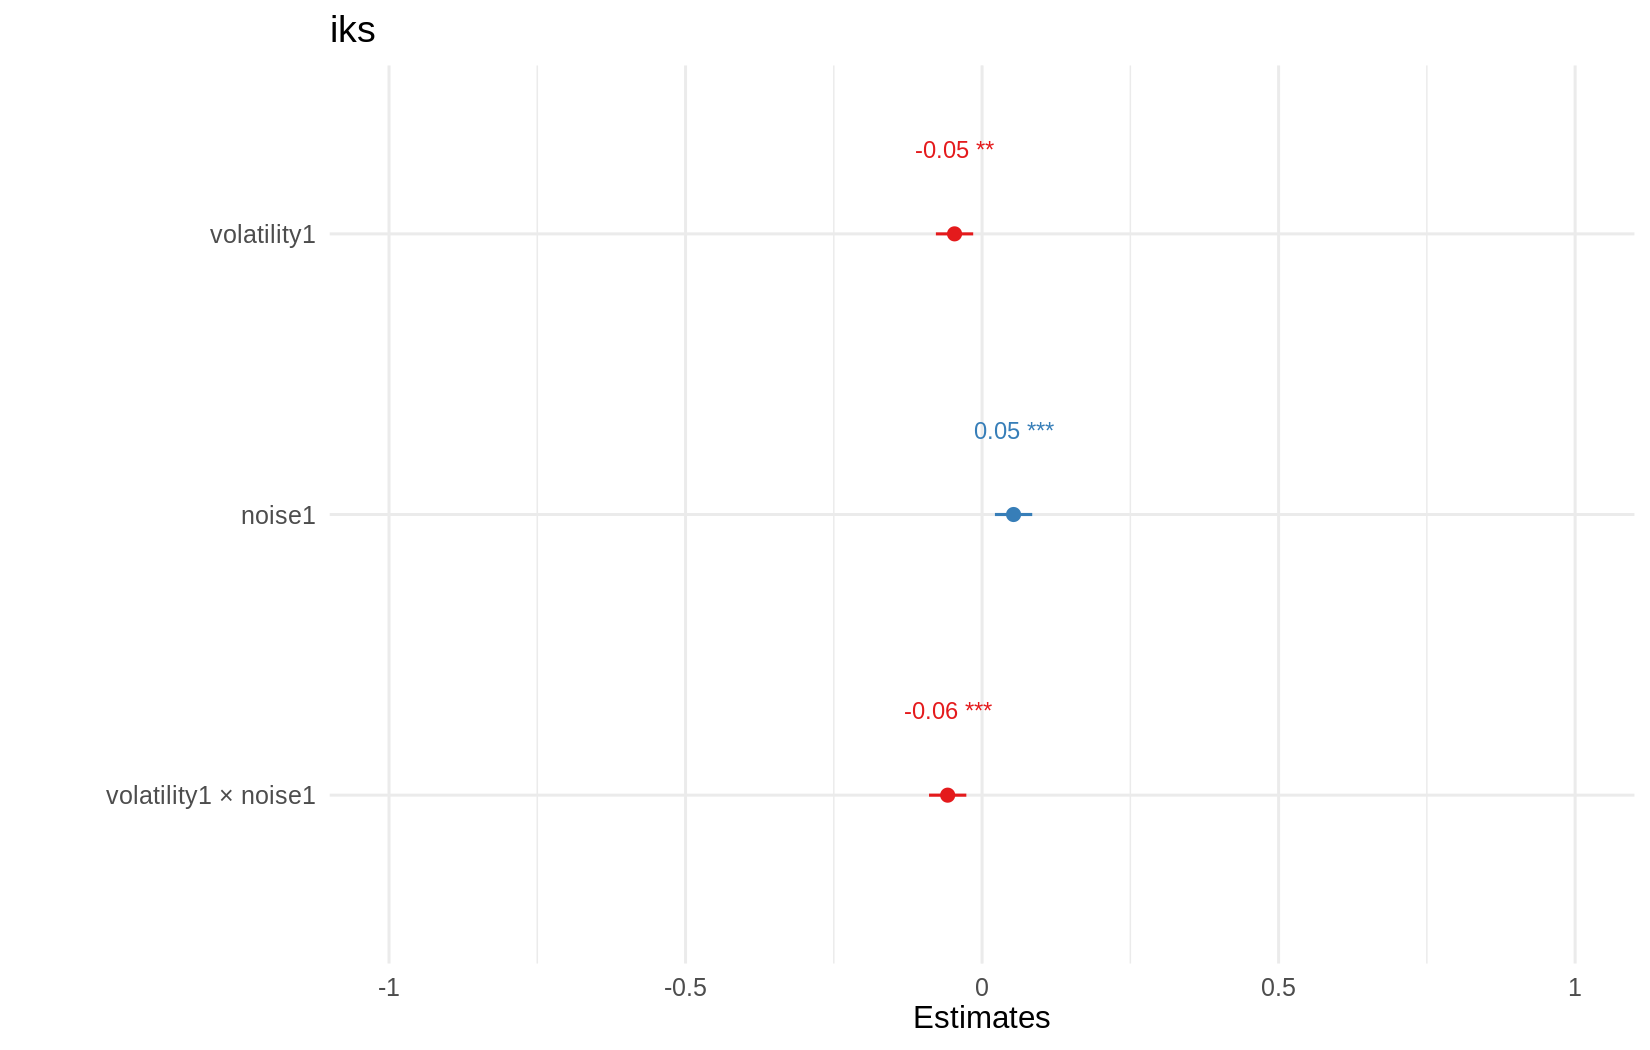

In [ ]:
options(
  repr.plot.width = 11,
  repr.plot.height = 7
)

p_fixed <- plot_model(
  model_iks,
  type = "est",
  show.values = TRUE,
  value.offset = 0.3
)

p_fixed

ggsave(
  file.path(
    output_dir,
    "iks_fixed_effects.png"
  ),
  p_fixed,
  width = 11,
  height = 7,
  dpi = 300
)


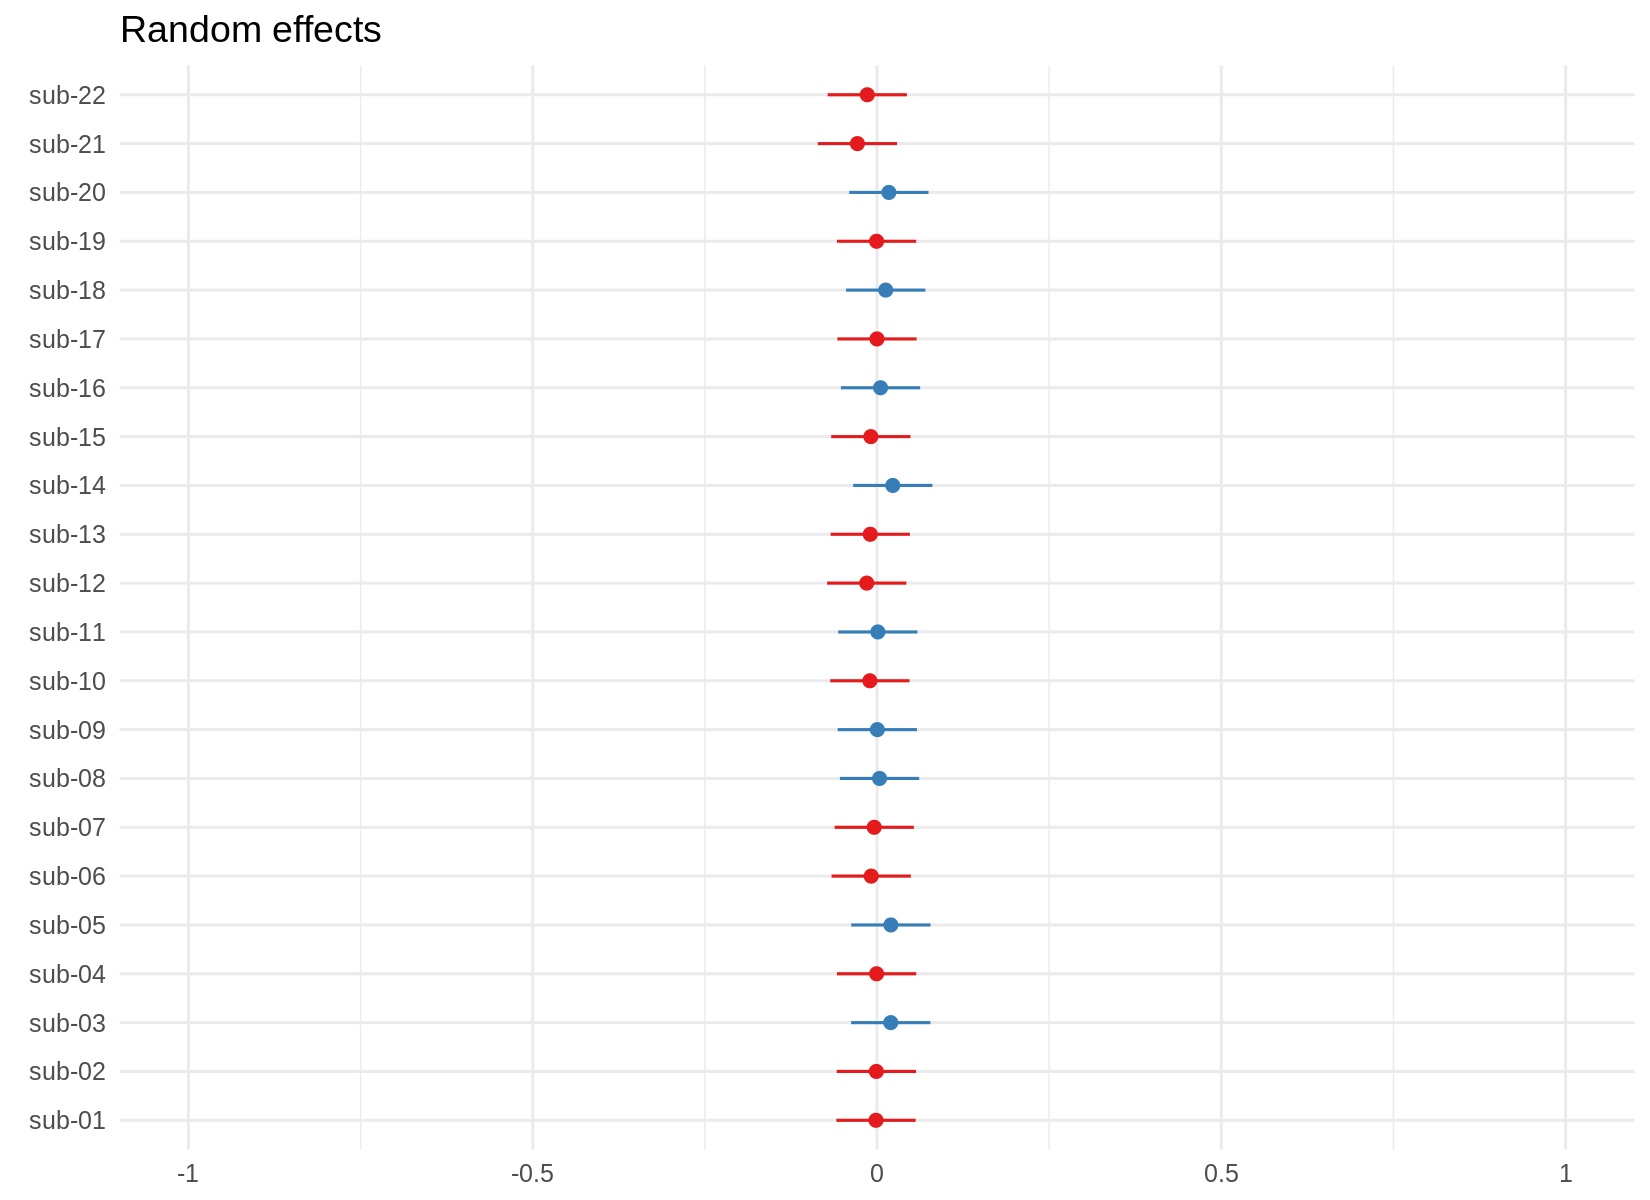

In [ ]:
options(
  repr.plot.width = 11,
  repr.plot.height = 8
)

p_random <- plot_model(
  model_iks,
  type = "re",
  order.terms = TRUE,
  sort.coef = "(Intercept)"
)

p_random

ggsave(
  file.path(
    output_dir,
    "iks_random_intercepts.png"
  ),
  p_random,
  width = 11,
  height = 8,
  dpi = 300
)


## 10. Model diagnostics


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


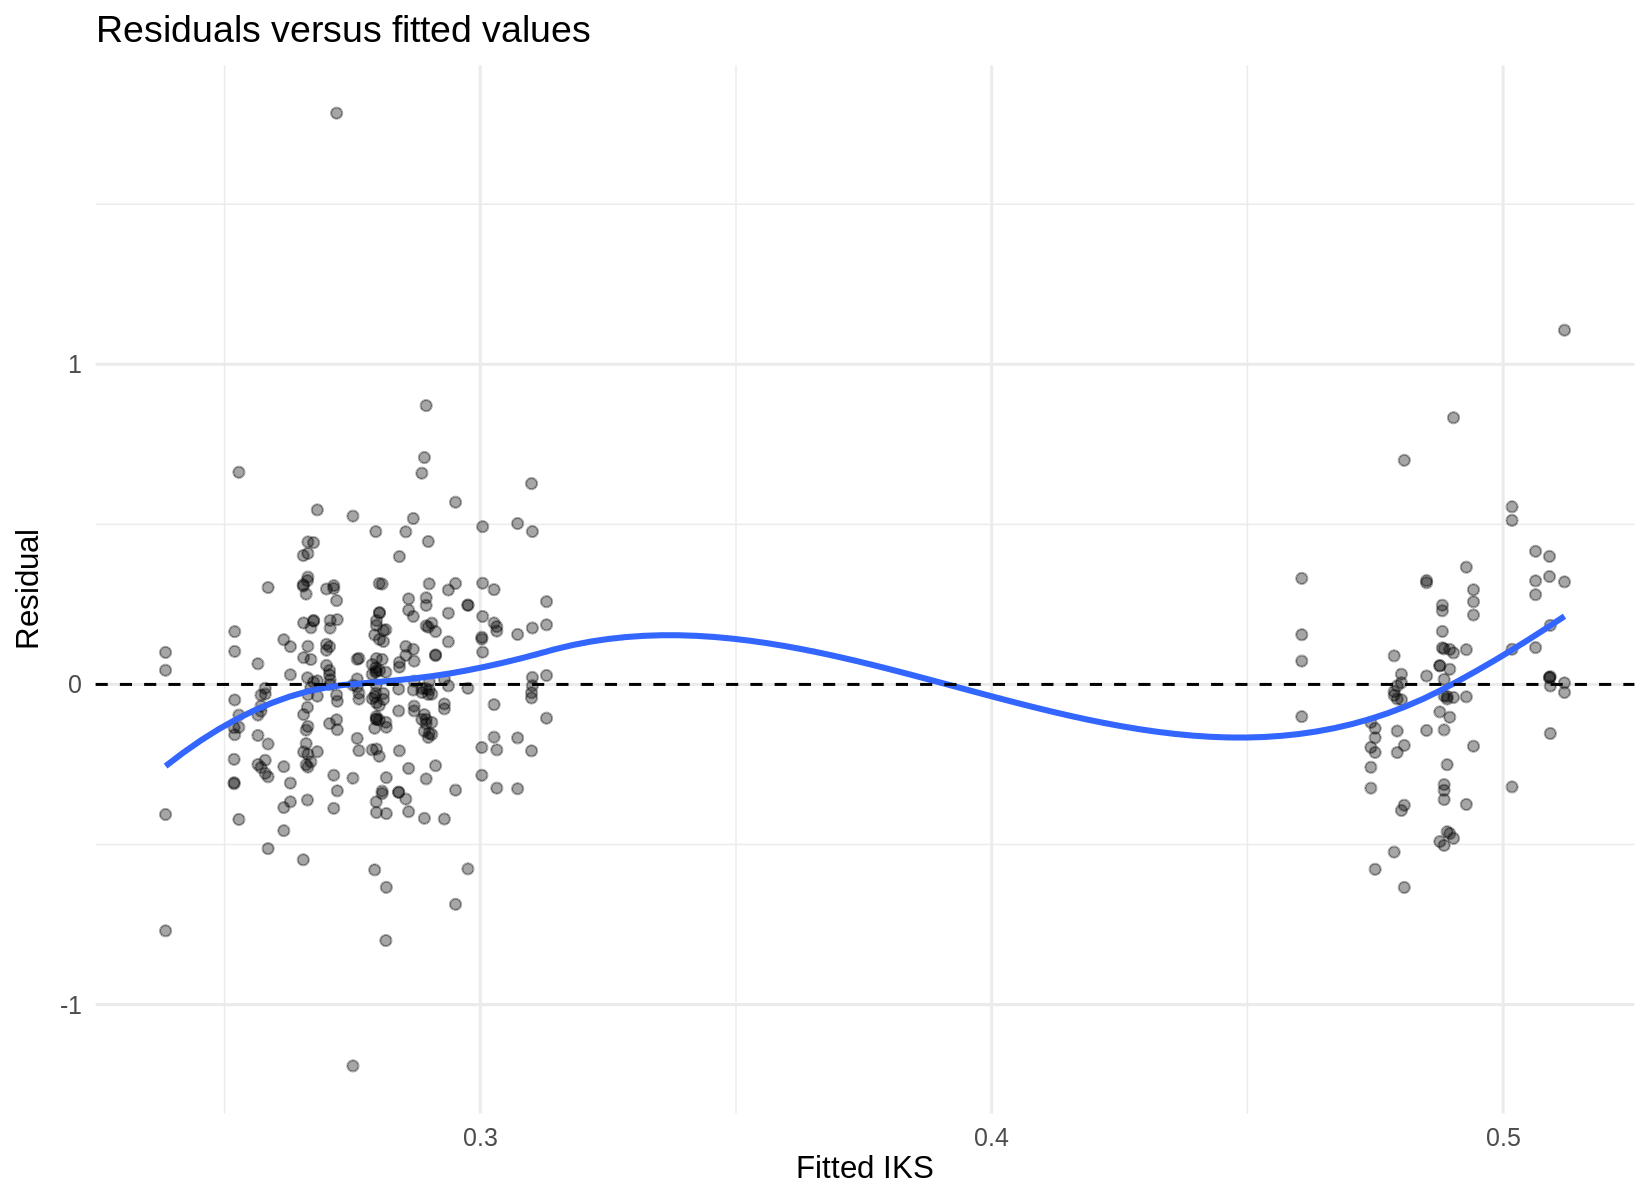

In [ ]:
diagnostic_data <- data.frame(
  fitted = fitted(model_iks),
  residual = resid(model_iks)
)

p_residuals <- ggplot(
  diagnostic_data,
  aes(
    x = fitted,
    y = residual
  )
) +
  geom_point(
    alpha = 0.35
  ) +
  geom_smooth(
    method = "loess",
    se = FALSE
  ) +
  geom_hline(
    yintercept = 0,
    linetype = "dashed"
  ) +
  labs(
    title = "Residuals versus fitted values",
    x = "Fitted IKS",
    y = "Residual"
  )

p_residuals

ggsave(
  file.path(
    output_dir,
    "iks_residuals_vs_fitted.png"
  ),
  p_residuals,
  width = 9,
  height = 6,
  dpi = 300
)


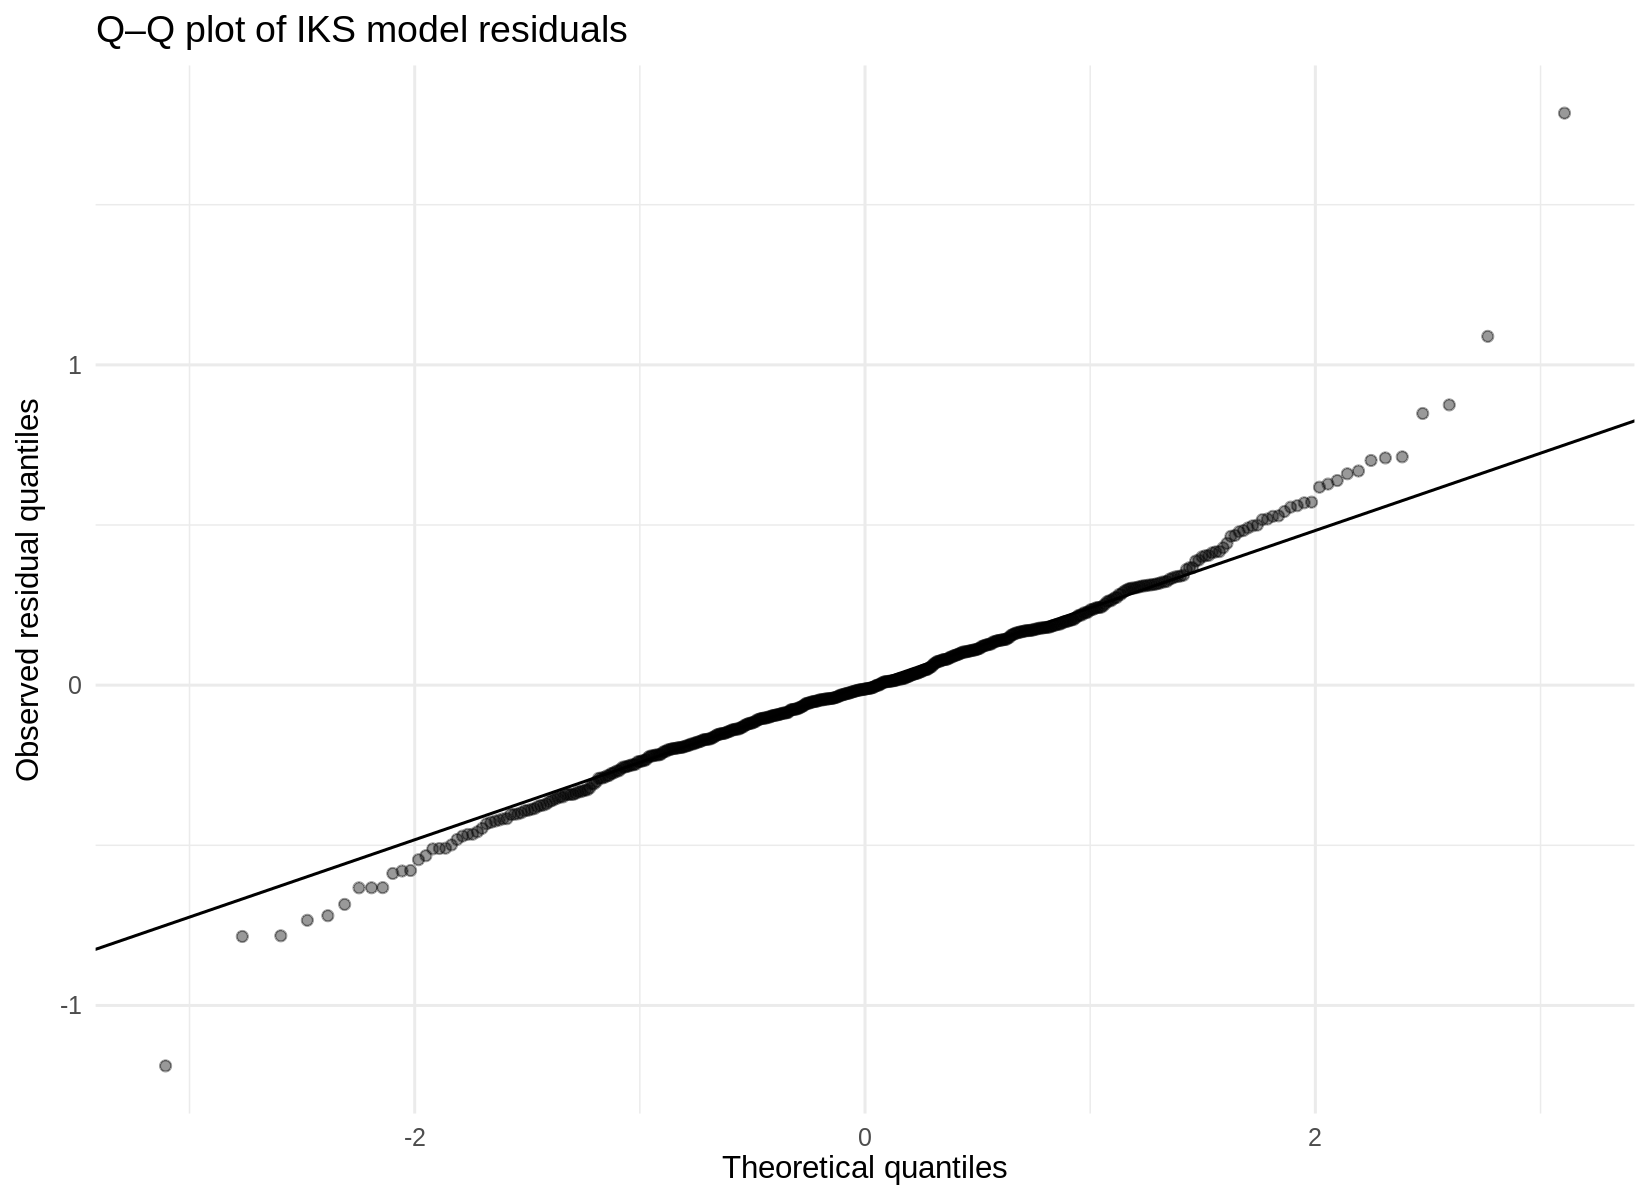

In [ ]:
p_qq <- ggplot(
  diagnostic_data,
  aes(
    sample = residual
  )
) +
  stat_qq(
    alpha = 0.4
  ) +
  stat_qq_line() +
  labs(
    title = "Q–Q plot of IKS model residuals",
    x = "Theoretical quantiles",
    y = "Observed residual quantiles"
  )

p_qq

ggsave(
  file.path(
    output_dir,
    "iks_residuals_qq.png"
  ),
  p_qq,
  width = 9,
  height = 6,
  dpi = 300
)


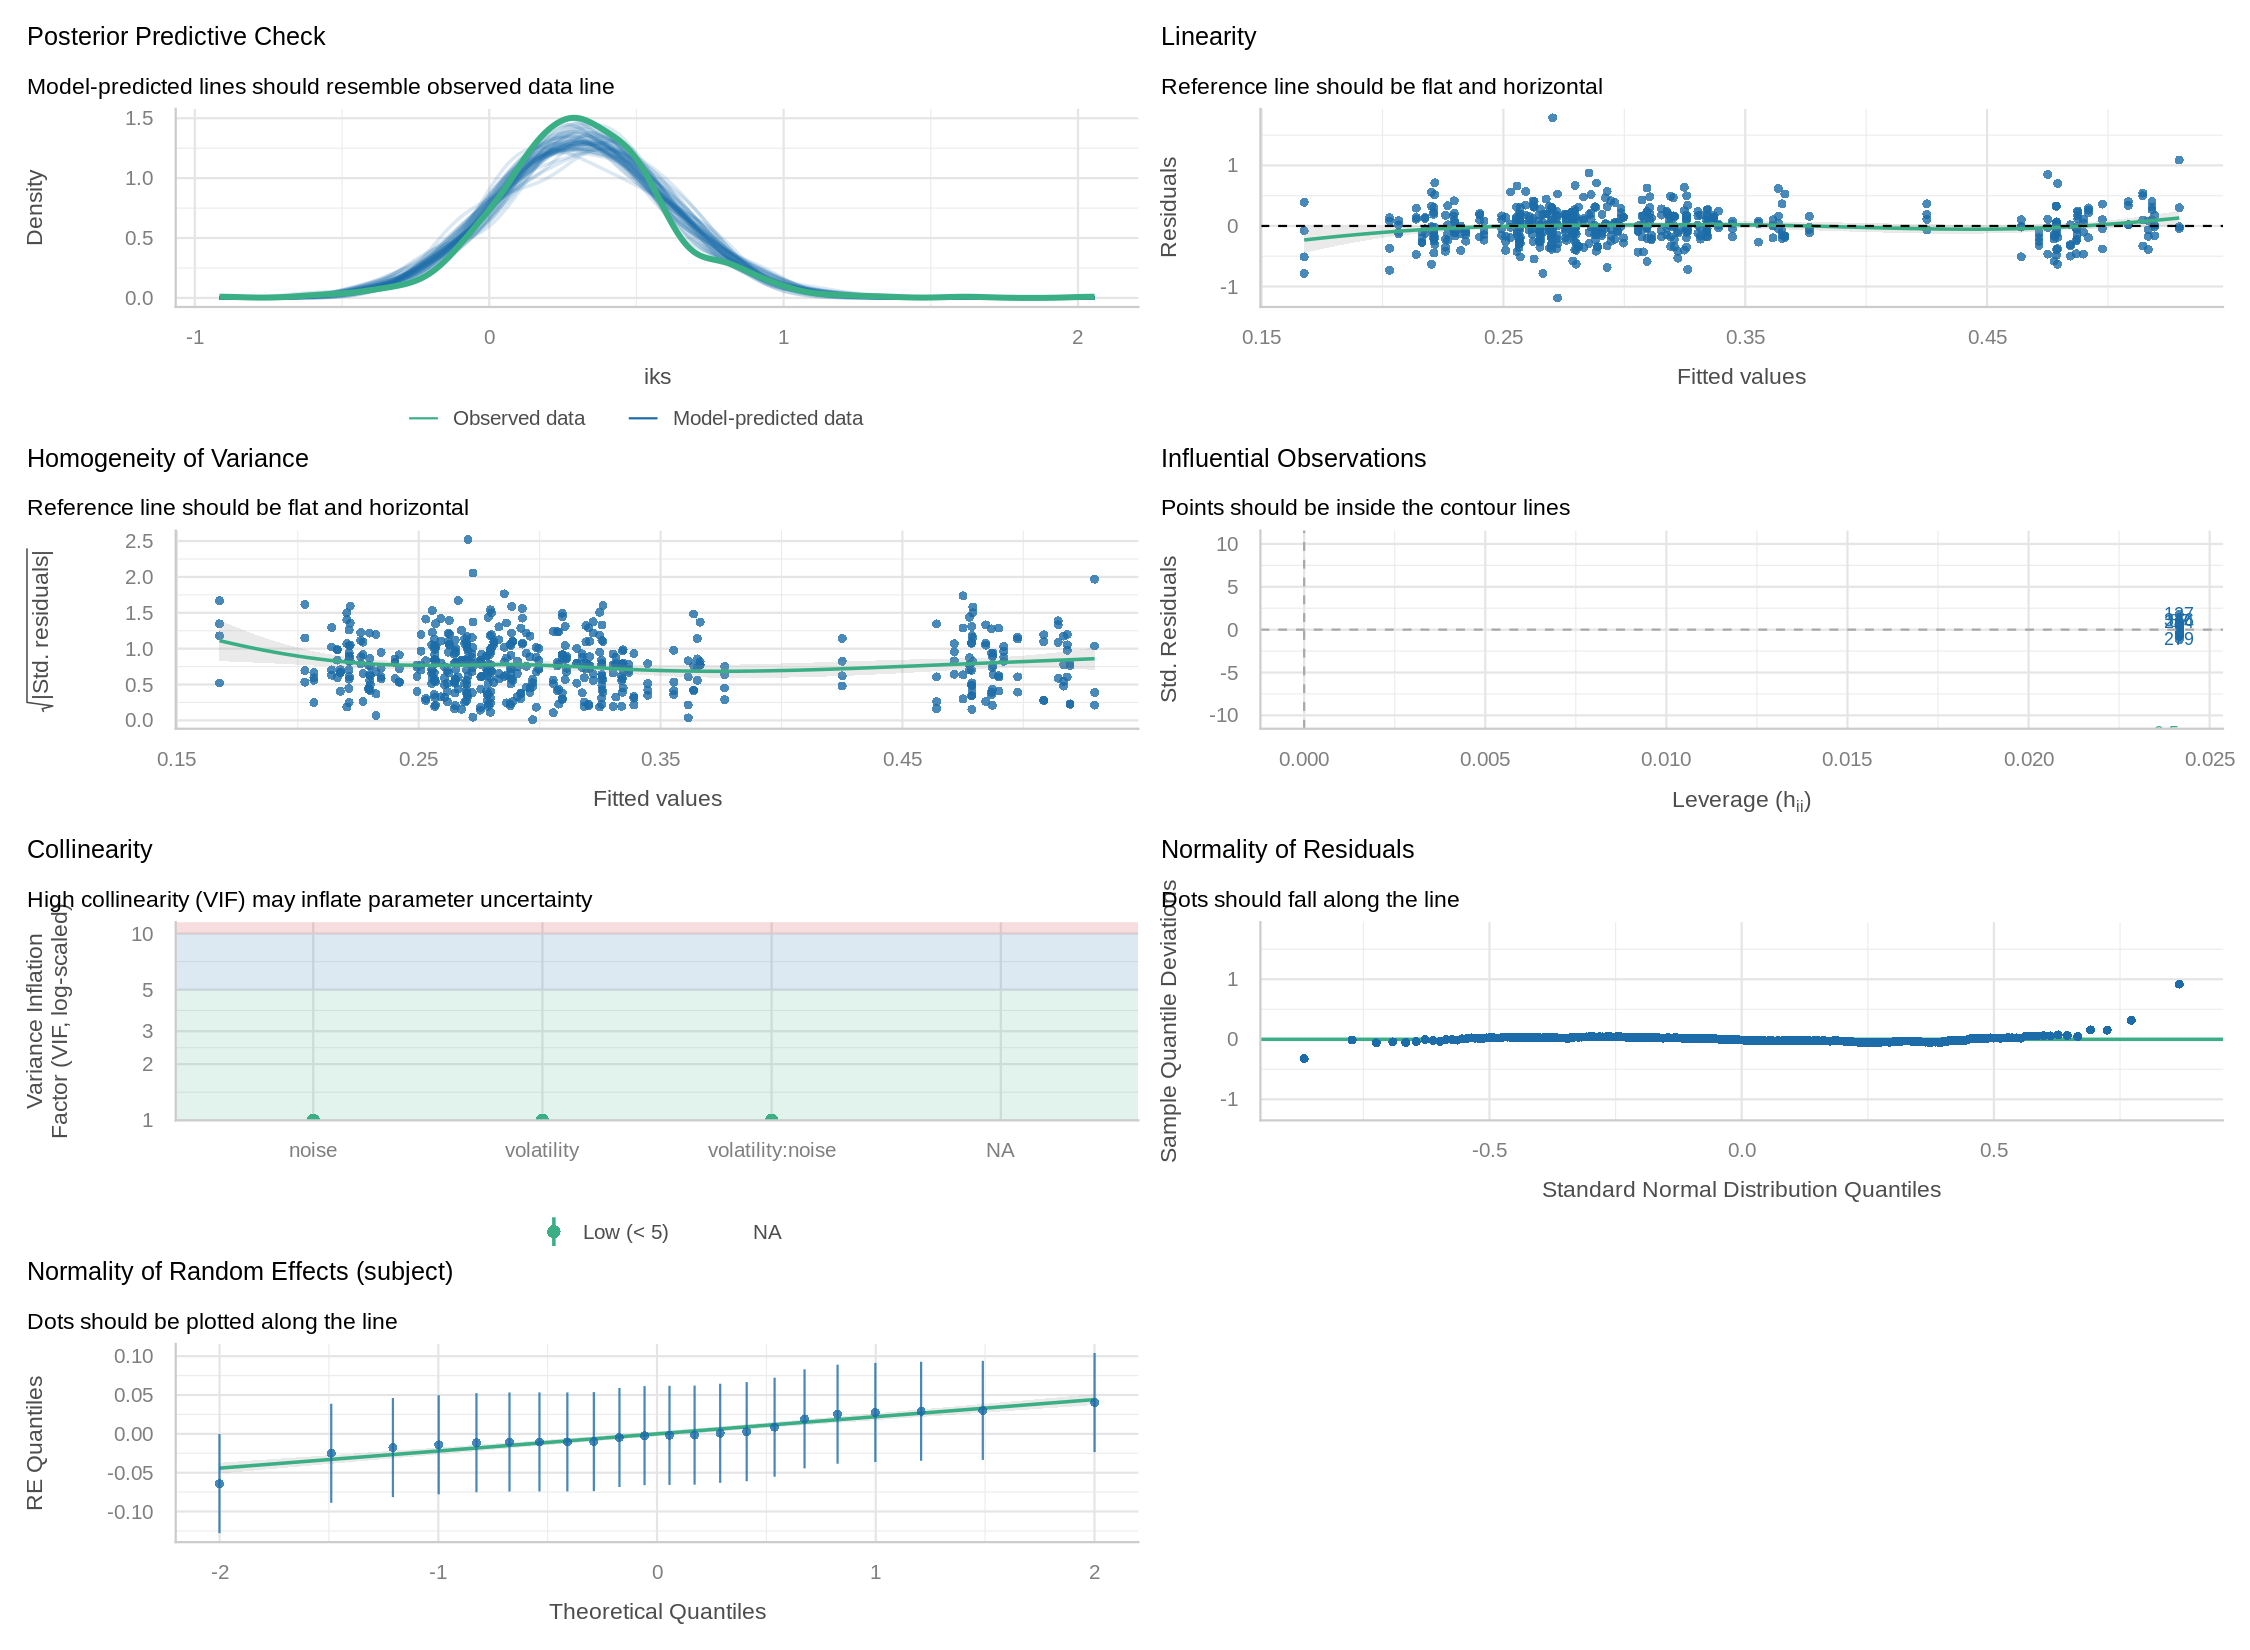

In [ ]:
options(
  repr.plot.width = 15,
  repr.plot.height = 11
)

check_model(model_iks)


## 11. Save model results


In [ ]:
fixed_effects <- as.data.frame(
  coef(
    summary(model_iks)
  )
)

fixed_effects$term <- rownames(
  fixed_effects
)

rownames(
  fixed_effects
) <- NULL


anova_table <- as.data.frame(
  anova_iks
)

anova_table$term <- rownames(
  anova_table
)

rownames(
  anova_table
) <- NULL


write_csv(
  fixed_effects,
  file.path(
    output_dir,
    "iks_fixed_effects.csv"
  )
)

write_csv(
  anova_table,
  file.path(
    output_dir,
    "iks_type3_anova.csv"
  )
)

write_csv(
  emm_iks_df,
  file.path(
    output_dir,
    "iks_estimated_marginal_means.csv"
  )
)

write_csv(
  posthoc_volatility,
  file.path(
    output_dir,
    "iks_posthoc_volatility_within_noise.csv"
  )
)

write_csv(
  posthoc_noise,
  file.path(
    output_dir,
    "iks_posthoc_noise_within_volatility.csv"
  )
)

write_csv(
  kernel_summary,
  file.path(
    output_dir,
    "iks_kernel_summary.csv"
  )
)

saveRDS(
  model_iks,
  file.path(
    output_dir,
    "iks_lmm_model.rds"
  )
)

cat(
  "All outputs were saved to:",
  normalizePath(output_dir),
  "\n"
)


All outputs were saved to: /content/iks_lmm_outputs 


## 12. Optional sensitivity analysis including session

The primary model follows the same structure as the RT and ELR analyses and treats subject as the repeated-measures grouping factor.

Because the IKS table contains four sessions per participant, this optional model tests whether the volatility/noise results remain similar after controlling for session as a fixed effect.


In [ ]:
model_iks_session <- lmer(
  iks ~
    volatility * noise +
    session +
    (1 | subject),
  data = iks_data,
  REML = FALSE
)

summary(model_iks_session)

anova(
  model_iks_session,
  type = 3,
  ddf = "Satterthwaite"
)


Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: iks ~ volatility * noise + session + (1 | subject)
   Data: iks_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    185.6     232.6     -81.8     163.6       517 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3514 -0.5704 -0.0333  0.5562  6.3648 

Random effects:
 Groups   Name        Variance Std.Dev.
 subject  (Intercept) 0.001583 0.03979 
 Residual             0.078514 0.28020 
Number of obs: 528, groups:  subject, 22

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)          0.283966   0.025822 170.552720  10.997  < 2e-16 ***
volatility1         -0.048360   0.012194 505.999997  -3.966 8.37e-05 ***
noise1               0.069019   0.017245 505.999997   4.002 7.22e-05 ***
noise2              -0.031816   0.017245 505.999997  -1.845  0.06563 .  
session2             0.034421   0.034491 505.999997   0.

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
volatility,1.2348508,1.23485084,1,506,15.727738,0.0000836922
noise,1.2601427,0.63007135,2,506,8.024935,0.0003706355
session,0.2591347,0.08637824,3,506,1.100161,0.3486165830
volatility:noise,1.1869312,0.59346562,2,506,7.558704,0.0005826112


## Dataset check used to build this notebook

The uploaded `iks_long.csv` contains:

- **528** total rows;
- **528** rows marked `valid_for_model = TRUE`;
- **22** participants;
- sessions: **1, 2, 3, 4**;
- volatility levels: **stable, volatile**;
- noise levels: **high, low, medium**;
- `n_valid_movements` ranges from **13** to **275**.

All rows in the uploaded file are currently valid for the primary IKS model.
